In [ ]:
# Cell 1: Colab Environment Setup
import os

if 'google.colab' in str(get_ipython()):
    REPO_NAME = "ICELLI-2026-Talk"
    REPO_URL = "https://github.com/codewithbello/ICELLI-2026-Talk.git"
    
    # 1. Clone repository if not already present
    if not os.path.exists(f"/content/{REPO_NAME}"):
        !git clone {REPO_URL}
        
    # 2. Set working directory to repo folder
    %cd /content/{REPO_NAME}
    print(f"✅ Ready! Working directory: {os.getcwd()}")


In [ ]:
"""
=====================================================================================================================
ICELLI 2026: TIME SERIES ANALYSIS IN SPACE PHYSICS: A PRACTICAL PYTHON WORKFLOW FOR IONOSPHERIC AND GEOMAGNETIC DATA
=====================================================================================================================
Presenter          : Bello Saeed Abioye
Affiliation        : Department of Physics, University of Ilorin
Email              : bello.sa@unilorin.edu.ng
ORCiD              : https://orcid.org/0000-0002-5527-1110

Key Learning Resources:
  - Python Official Documentation : https://www.python.org/
  - Pandas Getting Started Guides : https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html
  - Markdown Cheat Sheet Guide    : https://www.markdownguide.org/cheat-sheet/
  - SuperMAG Data Portal          : https://supermag.jhuapl.edu/
  - NASA OMNIWeb Data Explorer    : https://omniweb.gsfc.nasa.gov/form/dx1.html
  - INTERMAGNET Data Network      : https://intermagnet.org/
  - MAGDAS African Network        : Prof. Babatunde Rabiu (MAGDAS African POC & PI, Convener of ICELLI)

Key Scientific Literature:
  - A. B. Rabiu, A. I. Mamukuyomi and E. O. Joshua (2007). 
    "Variability of equatorial ionosphere inferred from geomagnetic field measurements."
    Bulletin of the Astronomical Society of India, 35, 607–618.

Observatory Information:
  - Station Name     : Ilorin, Nigeria (Station Code: ILR)
  - Coordinates      : Latitude: 8.50° N | Longitude: 4.68° E | Dip Equator Zone
  - Cadence          : 60-second (1-minute) and 1-hour resolution
  - Primary Currents : Solar Quiet (Sq) Current System, Equatorial Electrojet (EEJ)

Key Geomagnetic Parameters:
  - dbn_nez  : Northward magnetic field perturbation in geomagnetic NEZ coordinates (nT)
  - dbe_nez  : Eastward magnetic field perturbation in geomagnetic NEZ coordinates (nT)
  - dbz_nez  : Vertical (Downward) magnetic field perturbation in NEZ coordinates (nT)
  - H        : Total horizontal magnetic intensity: H = sqrt((dbn_nez)^2 + (dbe_nez)^2) (nT)
  - H_0      : Nighttime baseline value: H_0 = (H_23 + H_24 + H_1 + H_2) / 4 (nT)
  - ΔH (dH)  : Baseline-subtracted diurnal variation: ΔH = H - H_0 (nT)
  - BZ (GSM) : Interplanetary Magnetic Field (IMF) Z-component in GSM coordinates (nT)
  - Dst      : Disturbance Storm Time index measuring the equatorial ring current (nT)
========================================================================================
"""

# ICELLI 2026: Geomagnetic Data Analysis & Nighttime Baseline Estimation in Python
**Presenter:** Bello Saeed Abioye  
**Affiliation:** Department of Physics, University of Ilorin | [bello.sa@unilorin.edu.ng](mailto:bello.sa@unilorin.edu.ng)  
**ORCiD:** [https://orcid.org/0000-0002-5527-1110](https://orcid.org/0000-0002-5527-1110)  

---

### 🌍 Geomagnetic Coodinate

![Introduction to Geomagnetic Field- Campbell, 1997](geomagnetic.png)

### 🌍 Geomagnetic Baseline Methodology

![Nighttime Baseline Methodology — Rabiu et al. 2007](baseline_source.png)

In geomagnetic field studies, the solar quiet variation in the horizontal H component is isolated by subtracting the nighttime base level ($H_0$) from the horizontal H component. Following **Rabiu et al. (2007)** (*Bull. Astr. Soc. India*, 35, 607–618):

1. **Nighttime Baseline ($H_0$):** Defined as the average of the 4 hours flanking local midnight (23:00, 24:00, 01:00, 02:00 LT):
   $$H_0 = \frac{H_{23} + H_{24} + H_1 + H_2}{4}$$

2. **Hourly Departures ($\Delta H$):** The solar daily variation in H is obtained by subtracting the midnight baseline:
   $$\Delta H_t = H_t - H_0$$

---

### 📚 Data Sources:
- **SuperMAG Data Portal:** [https://supermag.jhuapl.edu/](https://supermag.jhuapl.edu/) (Global 1-minute ground magnetometer vectors)
- **NASA OMNIWeb Data Explorer:** [https://omniweb.gsfc.nasa.gov/form/dx1.html](https://omniweb.gsfc.nasa.gov/form/dx1.html) (Solar wind IMF $B_z$ & $Dst$ index)
- **INTERMAGNET & MAGDAS:** [https://intermagnet.org/](https://intermagnet.org/) / Prof. Babatunde Rabiu (MAGDAS African PI)

### Section 1: Importing Core Scientific Libraries & Setting Visual Styles
- **`pandas` & `numpy`**: Tabular manipulation, vectorized baseline calculations, time-series operations.
- **`xarray`**: Multi-dimensional NetCDF parsing directly into pandas DataFrames.
- **`matplotlib.pyplot`**: Publication-quality scientific figures and multi-panel dashboards.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Set modern scientific aesthetic for all figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

print("Core libraries imported successfully!")

Core libraries imported successfully!


### Section 2: Quick Introduction to Pandas Fundamentals
A fast primer on fundamental Pandas operations used throughout this tutorial:
1. **DataFrame creation** from dictionaries.
2. **Inspecting structures** (`head`, `tail`, `columns`, `dtypes`).
3. **Positional & Label Indexing** (`iloc`, `loc`).
4. **Boolean filtering** & column mathematical operations.

In [ ]:
# 1. Creating a DataFrame from a dictionary
sample_data = {
    'name': ['Alice', 'Bob', 'Charlie'],
    'age': [25, 30, 35],
    'city': ['New York', 'Los Angeles', 'Chicago']
}
demo_df = pd.DataFrame(sample_data)
print("--- Sample Pandas DataFrame ---")
print(demo_df)

# 2. Indexing with loc (label-based) and iloc (position-based)
print(f"\nloc sample [Row 0, 'name']: {demo_df.loc[0, 'name']}")
print(f"iloc sample [Row 0, Col 0]: {demo_df.iloc[0, 0]}")

# 3. Boolean filtering: Filter rows where age >= 30
filtered_demo = demo_df[demo_df['age'] >= 30]
print("\n--- Rows with Age >= 30 ---")
print(filtered_demo)

# 4. Mathematical transformation: Add a new column
demo_df['age_plus_10'] = demo_df['age'] + 10
print("\n--- DataFrame with Calculated Column ---")
print(demo_df)

### Section 3: Ingesting Single-Day SuperMAG CSV Data
In this section, we load a 1-day sample dataset from SuperMAG for Ilorin (Station code: `ILR`):
1. **Parse timestamps**: Convert ISO 8601 strings (`YYYY-MM-DDTHH:MM:SS`) to pandas `datetime` objects.
2. **Calculate Horizontal Intensity ($H$)**: Combine Northward ($N$) and Eastward ($E$) magnetic components:
   $$H = \sqrt{(\text{dbn\_nez})^2 + (\text{dbe\_nez})^2}$$
3. **Derive Fractional Decimal Hours**: Convert time into $0.0 - 24.0\text{ UT}$ for continuous diurnal plotting.

In [2]:
csv_filename = 'SuperMAG_60s_ILR_2009.csv'
df_day = pd.read_csv(csv_filename)

In [3]:
print(df_day.head())

              Date_UTC  Extent IAGA  GEOLON  GEOLAT    MLT  MCOLAT  IGRF_DECL  \
0  2009-01-01T00:00:00      60  ILR    4.68     8.5  23.95   96.48       0.32   
1  2009-01-01T00:01:00      60  ILR    4.68     8.5  23.96   96.48       0.32   
2  2009-01-01T00:02:00      60  ILR    4.68     8.5  23.98   96.48       0.32   
3  2009-01-01T00:03:00      60  ILR    4.68     8.5  24.00   96.48       0.32   
4  2009-01-01T00:04:00      60  ILR    4.68     8.5   0.01   96.48       0.32   

      SZA  dbn_nez  dbe_nez  dbz_nez  dbn_geo  dbe_geo  dbz_geo  
0  165.04  32802.1    -12.8  -4499.9  32772.3  -1399.2  -4499.9  
1  164.98  32802.3    -13.0  -4499.8  32772.4  -1399.5  -4499.8  
2  164.91  32802.3    -13.3  -4499.7  32772.4  -1399.7  -4499.7  
3  164.84  32802.3    -13.6  -4499.6  32772.4  -1400.0  -4499.6  
4  164.77  32802.4    -13.8  -4499.5  32772.5  -1400.3  -4499.5  


In [4]:
# Check data types
print(df_day.dtypes)

Date_UTC      object
Extent         int64
IAGA          object
GEOLON       float64
GEOLAT       float64
MLT          float64
MCOLAT       float64
IGRF_DECL    float64
SZA          float64
dbn_nez      float64
dbe_nez      float64
dbz_nez      float64
dbn_geo      float64
dbe_geo      float64
dbz_geo      float64
dtype: object


In [5]:
# Parse Date_UTC into standard pandas datetime
df_day['Date'] = pd.to_datetime(df_day['Date_UTC'], format='%Y-%m-%dT%H:%M:%S')
print(df_day.dtypes)

# print(df_day.head())

Date_UTC             object
Extent                int64
IAGA                 object
GEOLON              float64
GEOLAT              float64
MLT                 float64
MCOLAT              float64
IGRF_DECL           float64
SZA                 float64
dbn_nez             float64
dbe_nez             float64
dbz_nez             float64
dbn_geo             float64
dbe_geo             float64
dbz_geo             float64
Date         datetime64[ns]
dtype: object


In [6]:
# Compute total Horizontal Magnetic Intensity (H)
df_day['H'] = np.sqrt(df_day['dbn_nez']**2 + df_day['dbe_nez']**2)

In [7]:
# Calculate decimal hours (0.0 to 24.0 UT)
df_day['Hour'] = df_day['Date'].dt.hour + df_day['Date'].dt.minute / 60.0

print("--- Single-Day Magnetometer Data (CGGN/ILR) ---")
print(df_day[['Date', 'Hour', 'dbn_nez', 'dbe_nez', 'H']].head())

--- Single-Day Magnetometer Data (CGGN/ILR) ---
                 Date      Hour  dbn_nez  dbe_nez             H
0 2009-01-01 00:00:00  0.000000  32802.1    -12.8  32802.102497
1 2009-01-01 00:01:00  0.016667  32802.3    -13.0  32802.302576
2 2009-01-01 00:02:00  0.033333  32802.3    -13.3  32802.302696
3 2009-01-01 00:03:00  0.050000  32802.3    -13.6  32802.302819
4 2009-01-01 00:04:00  0.066667  32802.4    -13.8  32802.402903


### Section 4: Nighttime Baseline Estimation ($H_0$) & Baseline-Subtracted $\Delta H$
Using the methodology of **Rabiu et al. (2007)**:
- Isolate the 4 quiet nighttime hours: First 2 hours ($00:00 - 01:59\text{ UT}$) and last 2 hours ($22:00 - 23:59\text{ UT}$).
- Calculate the mean nighttime baseline $H_0$.
- Subtract $H_0$ from $H(t)$ to obtain $\Delta H(t) = H(t) - H_0$.

In [ ]:
# Step 1: Filter nighttime hours (Hour < 2 or Hour >= 22)
nighttime_day = df_day.loc[(df_day['Hour'] < 2) | (df_day['Hour'] >= 22), 'H']


In [9]:
# Step 2: Calculate nighttime baseline value (H0)
H0_single = nighttime_day.mean()
print(f"Calculated Nighttime Baseline (H0): {H0_single:.2f} nT")

Calculated Nighttime Baseline (H0): 32804.27 nT


In [12]:
# Step 3: Subtract baseline to derive diurnal variation ΔH
df_day['dH'] = df_day['H'] - H0_single

print(df_day[['Date', 'dH']].head())

                 Date        dH
0 2009-01-01 00:00:00 -2.171160
1 2009-01-01 00:01:00 -1.971082
2 2009-01-01 00:02:00 -1.970961
3 2009-01-01 00:03:00 -1.970838
4 2009-01-01 00:04:00 -1.870755


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Castush\AppData\Local\Temp\ipykernel_17656\3265119730.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Diurnal Variation of $\Delta H$ — Ilorin (ILR)\nDate: 2009-01-01 (Baseline $H_0 = {H0_single:.2f}$ nT)", fontsize=13, fontweight='bold')


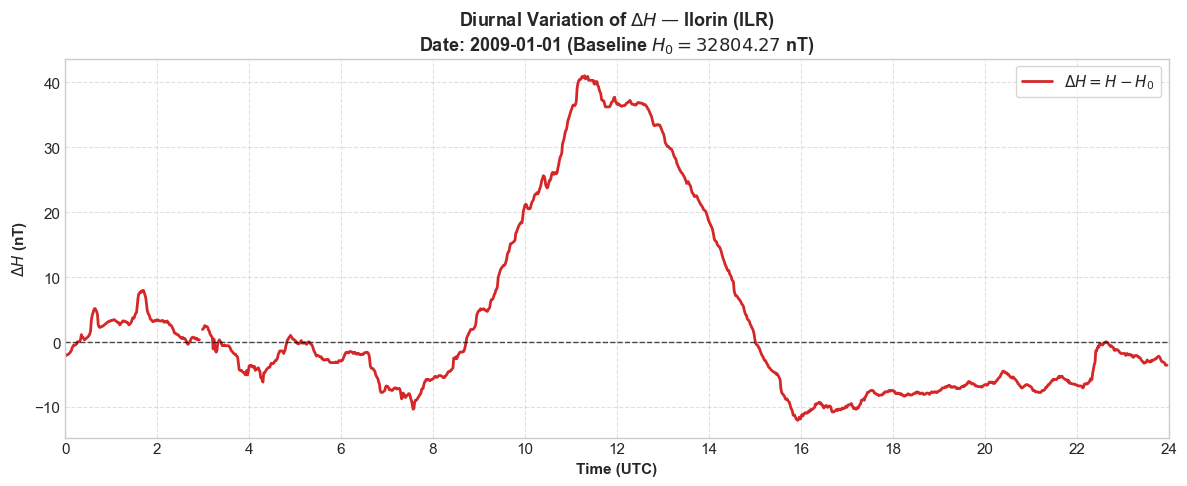

In [14]:
# Step 4: Plot Diurnal ΔH Variation
plt.figure(figsize=(12, 5))
plt.plot(df_day['Hour'], df_day['dH'], color='tab:red', linewidth=2, label=r'$\Delta H = H - H_0$')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Formatting and Styling
plt.title(f"Diurnal Variation of $\Delta H$ — Ilorin (ILR)\nDate: 2009-01-01 (Baseline $H_0 = {H0_single:.2f}$ nT)", fontsize=13, fontweight='bold')
plt.xlabel("Time (UTC)", fontsize=11, fontweight='bold')
plt.ylabel(r"$\Delta H$ (nT)", fontsize=11, fontweight='bold')
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

### Section 5: Solar Wind Driving ($B_z$) & Geomagnetic Storm Index ($Dst$)
Data from the **NASA OMNIWeb Data Explorer**:
- **$B_z$ (GSM)**: The Interplanetary Magnetic Field Z-component in Geocentric Solar Magnetospheric coordinates.
  * When $B_z < 0$ (Southward), magnetic reconnection occurs at Earth's magnetopause, transferring solar wind energy into the inner magnetosphere.
- **$Dst$ Index**: Disturbance Storm Time index (nT) tracking the intensity of the equatorial ring current.
- **Ground $\Delta H$**: The equatorial ground magnetometer response.

In [15]:
# IMF & Indices dataset
cols_indices = ['YEAR', 'DOY', 'HR', 'BZ_GSE', 'BZ_GSM', 'Dst']
indices_df = pd.read_table('indices_data.txt', sep=r'\s+', skiprows=6, names=cols_indices)

print(indices_df.head())

   YEAR  DOY  HR  BZ_GSE  BZ_GSM  Dst
0  2009    1   0     0.8     1.2   -7
1  2009    1   1    -0.1     0.1   -5
2  2009    1   2    -1.1    -0.8   -4
3  2009    1   3    -0.7    -0.5   -5
4  2009    1   4     0.2     0.0   -7


In [16]:
# Convert YEAR, DOY (Day of Year %j), and HR into datetime
indices_df['Date'] = pd.to_datetime(
    indices_df['YEAR'].astype(str) + ' ' + 
    indices_df['DOY'].astype(str) + ' ' + 
    indices_df['HR'].astype(str),
    format='%Y %j %H'
)

print(indices_df.head())

   YEAR  DOY  HR  BZ_GSE  BZ_GSM  Dst                Date
0  2009    1   0     0.8     1.2   -7 2009-01-01 00:00:00
1  2009    1   1    -0.1     0.1   -5 2009-01-01 01:00:00
2  2009    1   2    -1.1    -0.8   -4 2009-01-01 02:00:00
3  2009    1   3    -0.7    -0.5   -5 2009-01-01 03:00:00
4  2009    1   4     0.2     0.0   -7 2009-01-01 04:00:00


In [17]:
indices_df.rename(columns={'HR': 'Hour'}, inplace=True)

print("--- NASA OMNIWeb IMF & Geomagnetic Indices ---")
print(indices_df[['Date', 'Hour', 'BZ_GSM', 'Dst']].head())

--- NASA OMNIWeb IMF & Geomagnetic Indices ---
                 Date  Hour  BZ_GSM  Dst
0 2009-01-01 00:00:00     0     1.2   -7
1 2009-01-01 01:00:00     1     0.1   -5
2 2009-01-01 02:00:00     2    -0.8   -4
3 2009-01-01 03:00:00     3    -0.5   -5
4 2009-01-01 04:00:00     4     0.0   -7


### Section 6: 3-Panel Multi-Component Plots

1. **Panel (a)**: Interplanetary Magnetic Field $B_z$ (GSM) with highlighted southward reconnection intervals ($B_z < 0$).
2. **Panel (b)**: Geomagnetic $Dst$ Index showing ring current dynamics.
3. **Panel (c)**: Ground Baseline-Subtracted $\Delta H$ showing the daytime Equatorial Electrojet enhancement.

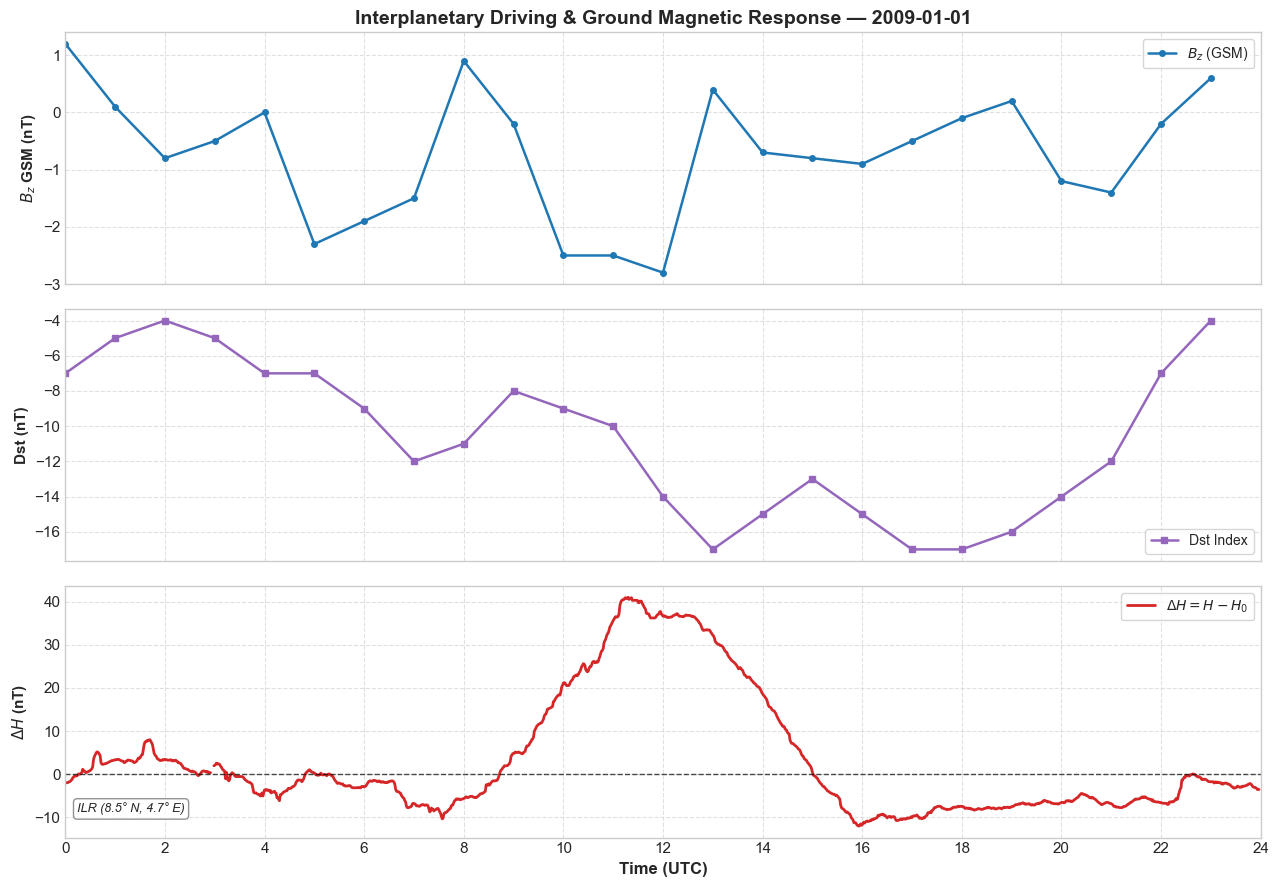

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13, 9), sharex=True)

# -------------------------------------------------------------
# Panel 1 (Top): Interplanetary Magnetic Field Bz (GSM)
# -------------------------------------------------------------
axes[0].plot(indices_df['Hour'], indices_df['BZ_GSM'], color='tab:blue', lw=1.8, marker='o', markersize=4, label=r'$B_z$ (GSM)')
# axes[0].axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
axes[0].set_ylabel(r'$B_z$ GSM (nT)', fontweight='bold')
axes[0].set_title("Interplanetary Driving & Ground Magnetic Response — 2009-01-01", fontsize=14, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right', frameon=True, fontsize=10)

# -------------------------------------------------------------
# Panel 2 (Middle): Geomagnetic Dst Index (Ring Current Intensity)
# -------------------------------------------------------------
axes[1].plot(indices_df['Hour'], indices_df['Dst'], color='tab:purple', lw=1.8, marker='s', markersize=4, label='Dst Index')
# axes[1].axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
axes[1].set_ylabel(r'Dst (nT)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='lower right', frameon=True, fontsize=10)

# -------------------------------------------------------------
# Panel 3 (Bottom):  ΔH (Ilorin)
# -------------------------------------------------------------
axes[2].plot(df_day['Hour'], df_day['dH'], color='tab:red', lw=2, label=r'$\Delta H = H - H_0$')
axes[2].axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
axes[2].set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
axes[2].set_ylabel(r'$\Delta H$ (nT)', fontweight='bold')
axes[2].set_xlim(0, 24)
axes[2].set_xticks(range(0, 25, 2))
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right', frameon=True, fontsize=10)

# Station annotation
axes[2].annotate(
    "ILR (8.5° N, 4.7° E)",
    xy=(0.01, 0.1), xycoords='axes fraction',
    fontsize=9, fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.tight_layout()
plt.show()

### Section 7: Scaling to Full 1-Year NetCDF Data with Xarray
When analyzing full years of 1-minute resolution data (525,600 observations):
1. **Ingest with `xarray`**: Automatically converts NetCDF arrays into a structured Pandas DataFrame.
2. **Compute Daily Baselines ($H_0$)**: Group all 365 days by calendar date to derive individual midnight baselines for every day in 2009.
3. **Monthly Diurnal Visualization**: Plot all observations for an entire month with the monthly mean curve.

In [21]:
netcdf_file = 'SuperMAG_60s_ILR_2009_rev-0006.1788318183.netcdf'

# Ingest full 1-year NetCDF using xarray
ds = xr.open_dataset(netcdf_file)
df_year = ds.to_dataframe().reset_index()

In [22]:
# Assemble standard datetime column
df_year['Time'] = pd.to_datetime({
    'year': df_year['time_yr'],
    'month': df_year['time_mo'],
    'day': df_year['time_dy'],
    'hour': df_year['time_hr'],
    'minute': df_year['time_mt'],
    'second': df_year['time_sc']
})

In [23]:
# Calculate H component and decimal hours
df_year['H'] = np.sqrt(df_year['dbn_nez']**2 + df_year['dbe_nez']**2)
df_year['Hour'] = df_year['Time'].dt.hour + df_year['Time'].dt.minute / 60.0

# Calculate Nighttime Baseline H0 for all 365 days in 2009
nighttime_year = df_year[(df_year['Hour'] < 2) | (df_year['Hour'] >= 22)]
daily_H0_all = nighttime_year.groupby(nighttime_year['Time'].dt.date)['H'].mean()

print(daily_H0_all)

Time
2009-01-01    32804.257812
2009-01-02    32799.269531
2009-01-03    32796.820312
2009-01-04    32796.593750
2009-01-05    32802.816406
                  ...     
2009-12-27             NaN
2009-12-28             NaN
2009-12-29             NaN
2009-12-30             NaN
2009-12-31             NaN
Name: H, Length: 365, dtype: float32


In [24]:
# Map daily baseline back and compute baseline-subtracted ΔH
df_year['H0'] = df_year['Time'].dt.date.map(daily_H0_all)
df_year['dH'] = df_year['H'] - df_year['H0']

print(f"--- 1-Year NetCDF Summary (Station ILR, 2009) ---")
print(f"Total 1-minute records: {len(df_year):,}")
print(f"Processed daily baselines: {len(daily_H0_all)} days")
print(df_year[['Time', 'Hour', 'H', 'H0', 'dH']].head())

--- 1-Year NetCDF Summary (Station ILR, 2009) ---
Total 1-minute records: 525,600
Processed daily baselines: 365 days
                 Time      Hour             H            H0        dH
0 2009-01-01 00:00:00  0.000000  32802.132812  32804.257812 -2.125000
1 2009-01-01 00:01:00  0.016667  32802.273438  32804.257812 -1.984375
2 2009-01-01 00:02:00  0.033333  32802.285156  32804.257812 -1.972656
3 2009-01-01 00:03:00  0.050000  32802.289062  32804.257812 -1.968750
4 2009-01-01 00:04:00  0.066667  32802.378906  32804.257812 -1.878906


### Section 8: Monthly Diurnal Variation Plot (January 2009)

- All 1 minute observations in semi-transparent gray ($s=6$).
- The monthly mean diurnal variation in bold red line showing the midday peak in $\Delta H$.

In [26]:
# Filter January 2009 from the 1-year dataset
jan_df = df_year[df_year['Time'].between('2009-01-01 00:00:00', '2009-01-31 23:59:59')].copy()

# Group by integer hour to calculate the monthly mean diurnal curve
jan_hourly_mean = jan_df.groupby(jan_df['Time'].dt.hour)['dH'].mean()



<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Castush\AppData\Local\Temp\ipykernel_17656\1459426173.py:14: SyntaxWarning: invalid escape sequence '\D'
  label='$\Delta H_avg$'
C:\Users\Castush\AppData\Local\Temp\ipykernel_17656\1459426173.py:21: SyntaxWarning: invalid escape sequence '\D'
  plt.title("Diurnal Variation of $\Delta H$ — Ilorin (ILR)\nMonth: January 2009", fontsize=14, fontweight='bold')


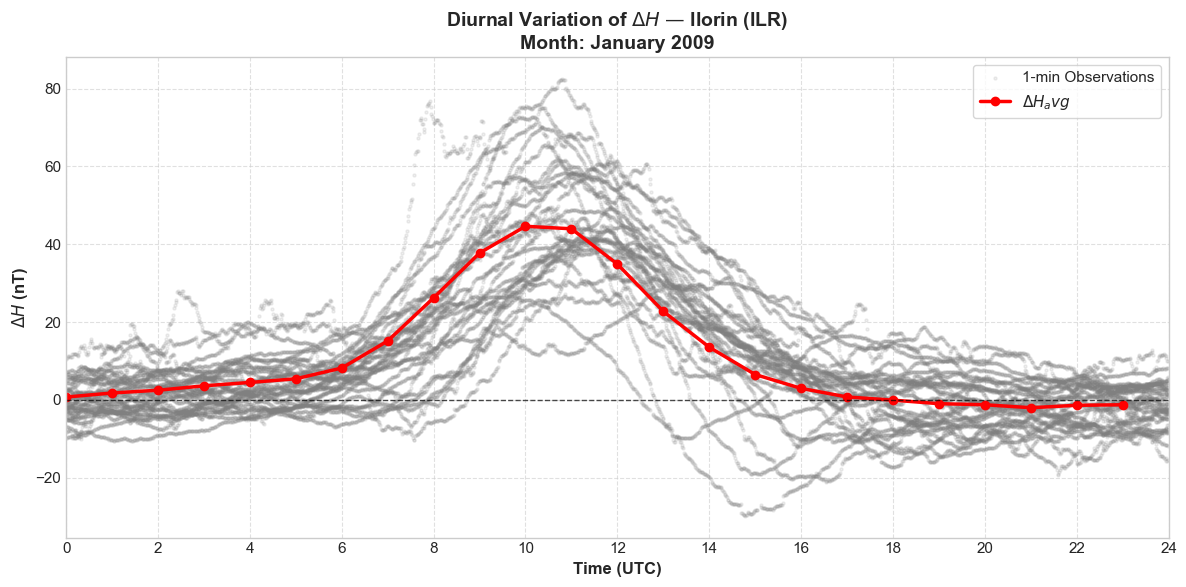


--- Geomagnetic Tutorial Script Completed Successfully! ---


In [27]:
plt.figure(figsize=(12, 6))

# 1. Scatter of all 1-minute measurements in January
plt.scatter(
    jan_df['Hour'], jan_df['dH'],
    color='gray', alpha=0.12, s=5,
    label='1-min Observations'
)

# 2. Monthly mean diurnal curve
plt.plot(
    jan_hourly_mean.index, jan_hourly_mean.values,
    color='red', marker='o', linewidth=2.5,
    label='$\Delta H_avg$'
)

# Reference zero baseline
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Formatting and Styling
plt.title("Diurnal Variation of $\Delta H$ — Ilorin (ILR)\nMonth: January 2009", fontsize=14, fontweight='bold')
plt.xlabel("Time (UTC)", fontsize=12, fontweight='bold')
plt.ylabel(r"$\Delta H$ (nT)", fontsize=12, fontweight='bold')
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

print("\n--- Geomagnetic Tutorial Script Completed Successfully! ---")